In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
from google.colab import drive
drive.mount('/content/drive')

df_raw = pd.read_csv('/content/drive/MyDrive/pie_sample_cleaned.csv')
print(f'Shape: {df_raw.shape}')
print(f'Target:\n{df_raw["target"].value_counts()}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Shape: (45891, 191)
Target:
target
0    34008
1    11883
Name: count, dtype: int64


In [25]:
import os
from google.colab import drive
drive.mount('/content/drive')

MULTI_PATH = '/content/drive/MyDrive/pie_sample_multirow.csv'

if os.path.exists(MULTI_PATH):
    df_multi = pd.read_csv(MULTI_PATH)
    print(f'Loaded existing multi-row: {df_multi.shape}')

else:
    print('Downloading train_data.csv via Kaggle API...')

    # Upload kaggle.json if not already present
    if not os.path.exists('/root/.kaggle/kaggle.json'):
        from google.colab import files
        print('Upload your kaggle.json when prompted...')
        files.upload()
        os.makedirs('/root/.kaggle', exist_ok=True)
        os.system('cp kaggle.json /root/.kaggle/')
        os.system('chmod 600 /root/.kaggle/kaggle.json')

    os.system('pip install kaggle -q')

    # Download only train_data.csv
    print('Downloading train_data.csv (16GB) — takes ~5 mins on Colab...')
    os.system('kaggle competitions download -c amex-default-prediction -f train_data.csv -p /content/')
    os.system('unzip -o /content/train_data.csv.zip -d /content/ 2>/dev/null || true')

    # Verify
    if os.path.exists('/content/train_data.csv'):
        size = os.path.getsize('/content/train_data.csv') / 1e9
        print(f'Downloaded: {size:.2f} GB')
    else:
        print('ERROR: download failed — check kaggle.json and competition acceptance')
        raise FileNotFoundError('train_data.csv not found after download')

    # Load sample IDs from cleaned CSV
    labels_df = pd.read_csv('/content/drive/MyDrive/pie_sample_cleaned.csv')[['customer_ID','target']]
    sample_ids = set(labels_df['customer_ID'].values)
    print(f'Sample IDs loaded: {len(sample_ids):,}')

    # Peek for dtypes
    TRAIN_PATH = '/content/train_data.csv'
    peek = pd.read_csv(TRAIN_PATH, nrows=1000)
    obj_cols = peek.select_dtypes(include='object').columns.tolist()
    dtype_map = {
        col: 'float32'
        for col in peek.columns
        if col not in obj_cols and col not in ['customer_ID', 'S_2']
    }
    print(f'String cols: {obj_cols}')
    print(f'Float32 cols: {len(dtype_map)}')

    # Chunk read — keep ALL rows per sampled customer (not just last)
    print('\nReading all statements for sampled customers...')
    parts = []
    for i, chunk in enumerate(pd.read_csv(TRAIN_PATH, chunksize=5000, dtype=dtype_map)):
        filtered = chunk[chunk['customer_ID'].isin(sample_ids)]
        if len(filtered):
            parts.append(filtered)
        if i % 200 == 0:
            import psutil
            ram = psutil.virtual_memory().percent
            print(f'  chunk {i} | parts collected: {len(parts)} | RAM: {ram:.1f}%')

    df_multi = pd.concat(parts, ignore_index=True)
    df_multi = df_multi.merge(labels_df, on='customer_ID')

    # Save to Drive immediately
    df_multi.to_csv(MULTI_PATH, index=False)
    print(f'\nSaved to Drive: {MULTI_PATH}')
    print(f'Shape: {df_multi.shape}')

print(f'\ndf_multi ready: {df_multi.shape}')
print(f'Unique customers: {df_multi["customer_ID"].nunique():,}')
print(f'Avg statements per customer: {len(df_multi)/df_multi["customer_ID"].nunique():.1f}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Upload your kaggle.json when prompted...


Saving kaggle.json to kaggle.json
Downloaded: 16.39 GB
Sample IDs loaded: 45,891
String cols: ['customer_ID', 'S_2', 'D_63', 'D_64']
Float32 cols: 186

Reading all statements for sampled customers...
  chunk 0 | parts collected: 1 | RAM: 16.7%
  chunk 200 | parts collected: 201 | RAM: 16.7%
  chunk 400 | parts collected: 401 | RAM: 17.1%
  chunk 600 | parts collected: 601 | RAM: 17.8%
  chunk 800 | parts collected: 801 | RAM: 18.3%
  chunk 1000 | parts collected: 1001 | RAM: 18.9%

Saved to Drive: /content/drive/MyDrive/pie_sample_multirow.csv
Shape: (553406, 191)

df_multi ready: (553406, 191)
Unique customers: 45,891
Avg statements per customer: 12.1


In [26]:
df_multi = df_multi.sort_values(['customer_ID', 'S_2'])

HIGH_MISSING = ['D_87','D_88','D_111','D_110','B_39','B_42',
                'D_73','D_108','D_138','D_136','D_135','D_134','D_137']

num_cols = [c for c in df_multi.columns
            if c not in ['customer_ID','S_2','target']
            and c not in HIGH_MISSING
            and df_multi[c].dtype != 'object']

print(f'Numeric cols for aggregation: {len(num_cols)}')
print('Building rich per-customer features...')

agg_dict = {}
for col in num_cols:
    agg_dict[f'{col}_last']  = (col, 'last')
    agg_dict[f'{col}_mean']  = (col, 'mean')
    agg_dict[f'{col}_std']   = (col, 'std')
    agg_dict[f'{col}_min']   = (col, 'min')
    agg_dict[f'{col}_max']   = (col, 'max')

df_agg = df_multi.groupby('customer_ID').agg(**agg_dict).reset_index()

stmt_count = df_multi.groupby('customer_ID')['S_2'].count().reset_index()
stmt_count.columns = ['customer_ID', 'stmt_count']
df_agg = df_agg.merge(stmt_count, on='customer_ID')

labels = df_multi[['customer_ID','target']].drop_duplicates()
df_agg = df_agg.merge(labels, on='customer_ID')

print(f'Aggregated shape: {df_agg.shape}')
print(f'Features generated: {df_agg.shape[1] - 2}')

Numeric cols for aggregation: 173
Building rich per-customer features...
Aggregated shape: (45891, 868)
Features generated: 866


In [27]:
print('Adding trend and range features...')

for col in num_cols[:60]:
    last_col  = f'{col}_last'
    mean_col  = f'{col}_mean'
    max_col   = f'{col}_max'
    min_col   = f'{col}_min'
    if last_col in df_agg.columns and mean_col in df_agg.columns:
        df_agg[f'{col}_trend'] = df_agg[last_col] - df_agg[mean_col]
    if max_col in df_agg.columns and min_col in df_agg.columns:
        df_agg[f'{col}_range'] = df_agg[max_col]  - df_agg[min_col]

print(f'Shape after trend/range: {df_agg.shape}')

Adding trend and range features...
Shape after trend/range: (45891, 988)


In [28]:
print('Adding ratio features...')

if 'B_1_last' in df_agg.columns and 'B_2_last' in df_agg.columns:
    df_agg['util_ratio']       = df_agg['B_1_last'] / (df_agg['B_2_last'] + 1e-6)
    df_agg['util_ratio_mean']  = df_agg['B_1_mean'] / (df_agg['B_2_mean'] + 1e-6)
    df_agg['util_trend']       = df_agg['util_ratio'] - df_agg['util_ratio_mean']

if 'P_2_last' in df_agg.columns and 'B_1_last' in df_agg.columns:
    df_agg['pay_to_bal']       = df_agg['P_2_last'] / (df_agg['B_1_last'] + 1e-6)
    df_agg['pay_to_bal_mean']  = df_agg['P_2_mean'] / (df_agg['B_1_mean'] + 1e-6)
    df_agg['pay_to_bal_trend'] = df_agg['pay_to_bal'] - df_agg['pay_to_bal_mean']

if 'S_3_last' in df_agg.columns and 'R_1_last' in df_agg.columns:
    df_agg['spend_risk']       = df_agg['S_3_last'] / (df_agg['R_1_last'] + 1e-6)

d_trend_cols = [c for c in df_agg.columns if c.startswith('D_') and c.endswith('_trend')]
b_std_cols   = [c for c in df_agg.columns if c.startswith('B_') and c.endswith('_std')]
r_last_cols  = [c for c in df_agg.columns if c.startswith('R_') and c.endswith('_last')]

if d_trend_cols:
    df_agg['delinq_trend_sum'] = df_agg[d_trend_cols].sum(axis=1)
    df_agg['delinq_trend_max'] = df_agg[d_trend_cols].max(axis=1)
if b_std_cols:
    df_agg['bal_volatility']   = df_agg[b_std_cols].mean(axis=1)
if r_last_cols:
    df_agg['risk_composite']   = df_agg[r_last_cols].mean(axis=1)

print(f'Final shape: {df_agg.shape}')

Adding ratio features...
Final shape: (45891, 999)


In [29]:
DROP = ['customer_ID', 'target']
X = df_agg.drop(columns=DROP)
y = df_agg['target']

X = X.fillna(X.median())
X = X.replace([np.inf, -np.inf], 0)

print(f'X shape: {X.shape}')
print(f'Missing: {X.isnull().sum().sum()}')
print(f'Inf: {np.isinf(X.values).sum()}')
print(f'Target:\n{y.value_counts()}')

X shape: (45891, 997)
Missing: 0
Inf: 0
Target:
target
0    34008
1    11883
Name: count, dtype: int64


In [31]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
scale_pos_weight = neg / pos

print(f'Train: {X_train.shape} | Test: {X_test.shape}')
print(f'scale_pos_weight: {scale_pos_weight:.2f}')

Train: (36712, 997) | Test: (9179, 997)
scale_pos_weight: 2.86


In [32]:
import lightgbm as lgb

model = lgb.LGBMClassifier(
    n_estimators=3000,
    learning_rate=0.01,
    max_depth=8,
    num_leaves=63,
    min_child_samples=20,
    scale_pos_weight=scale_pos_weight,
    subsample=0.7,
    subsample_freq=1,
    colsample_bytree=0.6,
    reg_alpha=0.1,
    reg_lambda=2.0,
    min_split_gain=0.01,
    random_state=42,
    n_jobs=-1,
    verbose=-1
)

model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    callbacks=[lgb.early_stopping(150), lgb.log_evaluation(300)]
)

print(f'Best iteration: {model.best_iteration_}')

Training until validation scores don't improve for 150 rounds
[300]	valid_0's binary_logloss: 0.268074
[600]	valid_0's binary_logloss: 0.255167
[900]	valid_0's binary_logloss: 0.248508
[1200]	valid_0's binary_logloss: 0.245348
[1500]	valid_0's binary_logloss: 0.243753
[1800]	valid_0's binary_logloss: 0.243639
Early stopping, best iteration is:
[1722]	valid_0's binary_logloss: 0.243453
Best iteration: 1722


ROC-AUC: 0.9570
              precision    recall  f1-score   support

 Non-Default       0.95      0.90      0.93      6802
     Default       0.76      0.87      0.81      2377

    accuracy                           0.89      9179
   macro avg       0.85      0.89      0.87      9179
weighted avg       0.90      0.89      0.90      9179



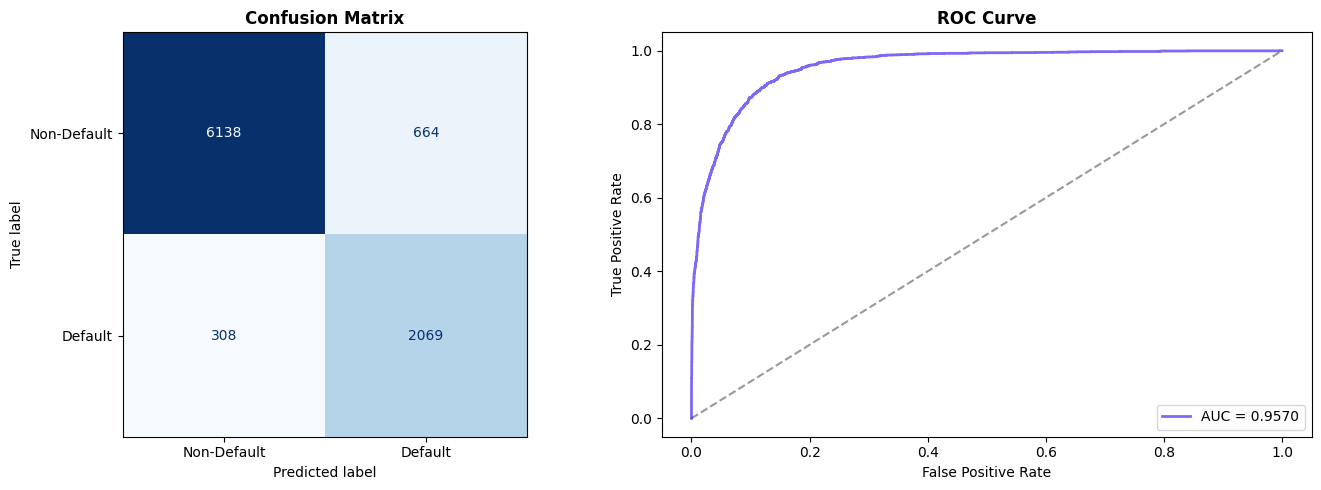

In [33]:
from sklearn.metrics import (classification_report, roc_auc_score,
                             confusion_matrix, ConfusionMatrixDisplay, roc_curve)

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

auc = roc_auc_score(y_test, y_prob)
print(f'ROC-AUC: {auc:.4f}')
print(classification_report(y_test, y_pred, target_names=['Non-Default','Default']))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=['Non-Default','Default']).plot(
    ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Confusion Matrix', fontweight='bold')

fpr, tpr, _ = roc_curve(y_test, y_prob)
axes[1].plot(fpr, tpr, color='#7c6af7', lw=2, label=f'AUC = {auc:.4f}')
axes[1].plot([0,1],[0,1],'k--',alpha=0.4)
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve', fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/model_evaluation_v2.png', dpi=120, bbox_inches='tight')
plt.show()

Best accuracy → threshold=0.64 accuracy=0.8987
Best macro F1 → threshold=0.63  f1=0.8690


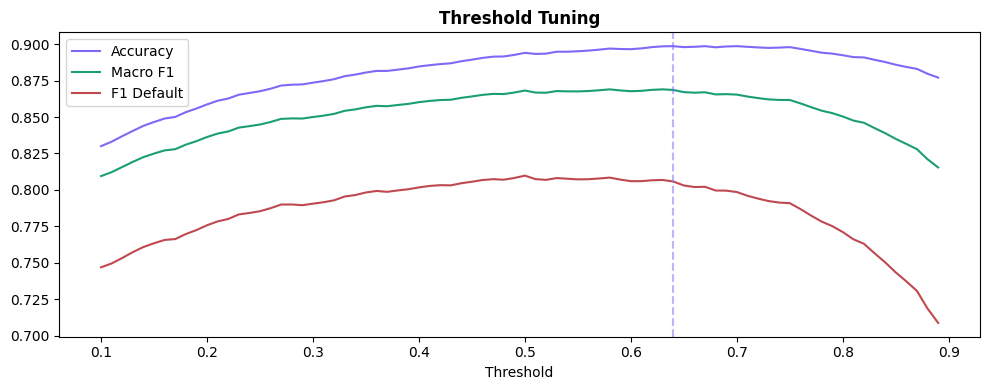


Final report at threshold=0.64:
              precision    recall  f1-score   support

 Non-Default       0.93      0.93      0.93      6802
     Default       0.80      0.81      0.81      2377

    accuracy                           0.90      9179
   macro avg       0.87      0.87      0.87      9179
weighted avg       0.90      0.90      0.90      9179



In [34]:
from sklearn.metrics import f1_score, accuracy_score

thresholds = np.arange(0.1, 0.9, 0.01)
scores = []
for t in thresholds:
    preds = (y_prob >= t).astype(int)
    scores.append({
        'threshold':  t,
        'accuracy':   accuracy_score(y_test, preds),
        'f1_macro':   f1_score(y_test, preds, average='macro'),
        'f1_default': f1_score(y_test, preds, pos_label=1)
    })

scores_df = pd.DataFrame(scores)
best_acc_row = scores_df.loc[scores_df['accuracy'].idxmax()]
best_f1_row  = scores_df.loc[scores_df['f1_macro'].idxmax()]

print(f'Best accuracy → threshold={best_acc_row["threshold"]:.2f} accuracy={best_acc_row["accuracy"]:.4f}')
print(f'Best macro F1 → threshold={best_f1_row["threshold"]:.2f}  f1={best_f1_row["f1_macro"]:.4f}')

plt.figure(figsize=(10,4))
plt.plot(scores_df['threshold'], scores_df['accuracy'],   label='Accuracy',   color='#7c6af7')
plt.plot(scores_df['threshold'], scores_df['f1_macro'],   label='Macro F1',   color='#1a9e75')
plt.plot(scores_df['threshold'], scores_df['f1_default'], label='F1 Default', color='#c04850')
plt.axvline(best_acc_row['threshold'], linestyle='--', alpha=0.5, color='#7c6af7')
plt.xlabel('Threshold')
plt.title('Threshold Tuning', fontweight='bold')
plt.legend()
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/threshold_tuning_v2.png', dpi=120, bbox_inches='tight')
plt.show()

BEST_THRESHOLD = float(best_acc_row['threshold'])
y_pred_tuned = (y_prob >= BEST_THRESHOLD).astype(int)
print(f'\nFinal report at threshold={BEST_THRESHOLD:.2f}:')
print(classification_report(y_test, y_pred_tuned, target_names=['Non-Default','Default']))

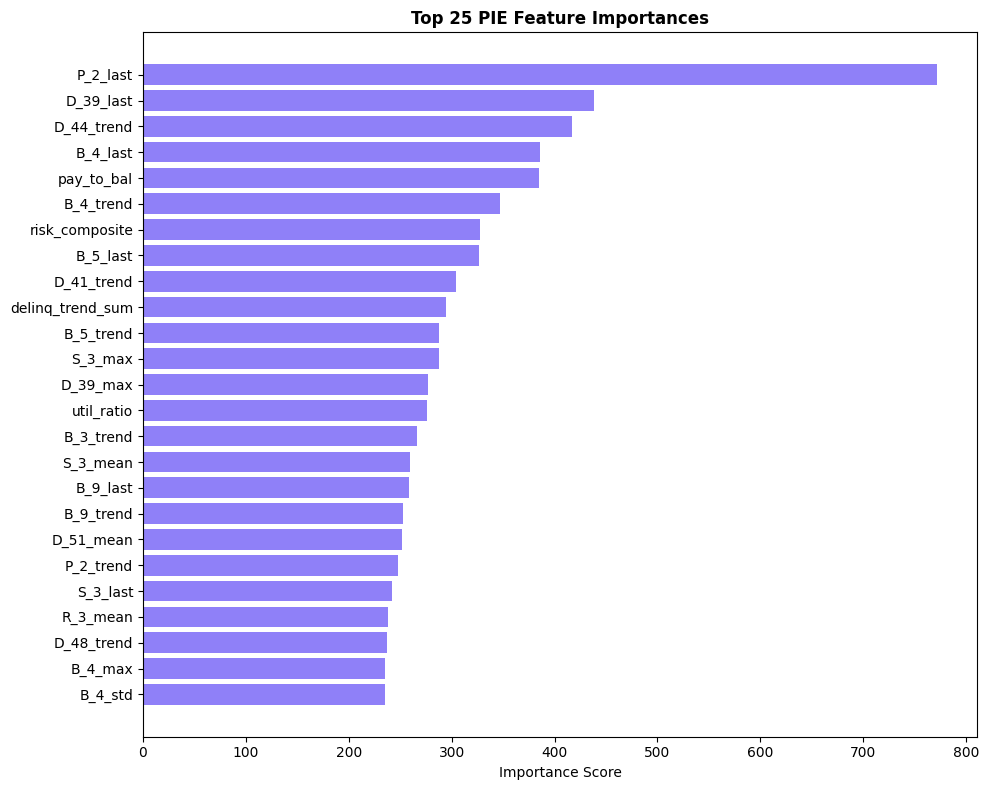

Top 10:
         feature  importance
        P_2_last         772
       D_39_last         438
      D_44_trend         417
        B_4_last         386
      pay_to_bal         385
       B_4_trend         347
  risk_composite         328
        B_5_last         327
      D_41_trend         304
delinq_trend_sum         295


In [35]:
importance = pd.DataFrame({
    'feature':    X.columns,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False).head(25)

plt.figure(figsize=(10, 8))
plt.barh(importance['feature'][::-1], importance['importance'][::-1],
         color='#7c6af7', alpha=0.85)
plt.xlabel('Importance Score')
plt.title('Top 25 PIE Feature Importances', fontweight='bold')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/feature_importance_v2.png', dpi=120, bbox_inches='tight')
plt.show()

print('Top 10:')
print(importance[['feature','importance']].head(10).to_string(index=False))

In [36]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

cv_model = lgb.LGBMClassifier(
    n_estimators=500,
    learning_rate=0.01,
    max_depth=8,
    num_leaves=63,
    scale_pos_weight=scale_pos_weight,
    subsample=0.7,
    colsample_bytree=0.6,
    reg_alpha=0.1,
    reg_lambda=2.0,
    random_state=42,
    n_jobs=-1,
    verbose=-1
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(cv_model, X, y, cv=cv, scoring='roc_auc', n_jobs=-1)

print(f'5-Fold CV AUC: {cv_scores.round(4)}')
print(f'Mean AUC: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')

5-Fold CV AUC: [0.957  0.9537 0.9558 0.9584 0.9569]
Mean AUC: 0.9564 ± 0.0016


In [37]:
import pickle

MODEL_PATH     = '/content/drive/MyDrive/pie_lightgbm_model_v2.pkl'
FEATURES_PATH  = '/content/drive/MyDrive/pie_feature_columns_v2.pkl'
THRESHOLD_PATH = '/content/drive/MyDrive/pie_threshold_v2.pkl'

with open(MODEL_PATH, 'wb') as f:
    pickle.dump(model, f)
with open(FEATURES_PATH, 'wb') as f:
    pickle.dump(list(X.columns), f)
with open(THRESHOLD_PATH, 'wb') as f:
    pickle.dump(BEST_THRESHOLD, f)

sample_probs = model.predict_proba(X_test[:5])[:, 1]
print('Sample PIE risk scores:')
for i, p in enumerate(sample_probs):
    score = round(float(p) * 100, 2)
    bucket = ('LOW_RISK'      if score < 30 else
              'HIGH_RISK'     if score < 60 else
              'CRITICAL'      if score < 80 else
              'VERY_CRITICAL')
    print(f'  Customer {i+1}: score={score:5.1f} → {bucket}')

print(f'\nSaved to Drive:')
print(f'  {MODEL_PATH}')
print(f'  {FEATURES_PATH}')
print(f'  {THRESHOLD_PATH}')
print('\nPart 2 complete.')

Sample PIE risk scores:
  Customer 1: score= 45.6 → HIGH_RISK
  Customer 2: score=  0.6 → LOW_RISK
  Customer 3: score=  1.0 → LOW_RISK
  Customer 4: score=  4.2 → LOW_RISK
  Customer 5: score= 13.5 → LOW_RISK

Saved to Drive:
  /content/drive/MyDrive/pie_lightgbm_model_v2.pkl
  /content/drive/MyDrive/pie_feature_columns_v2.pkl
  /content/drive/MyDrive/pie_threshold_v2.pkl

Part 2 complete.
